In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
x = df.drop("charges", axis=1)
y = df["charges"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
model = LinearRegression()
model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred = model.predict(x_test)

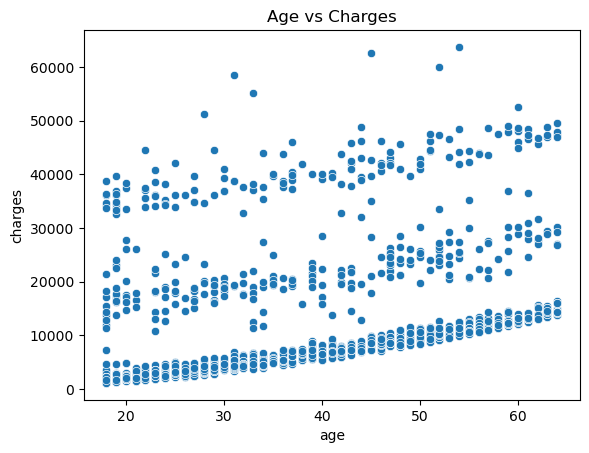

In [13]:
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Charges")
plt.show()

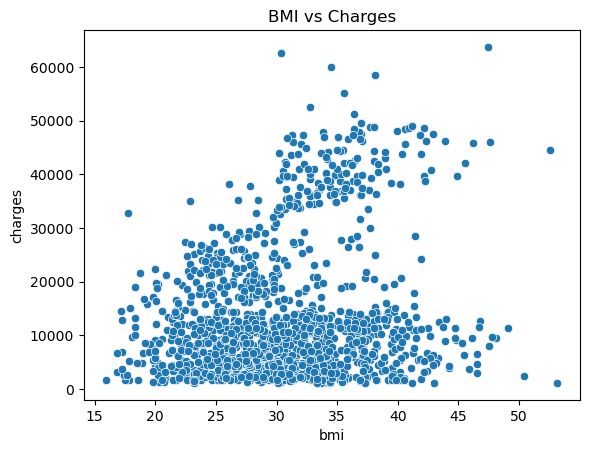

In [16]:
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Charges")
plt.show()

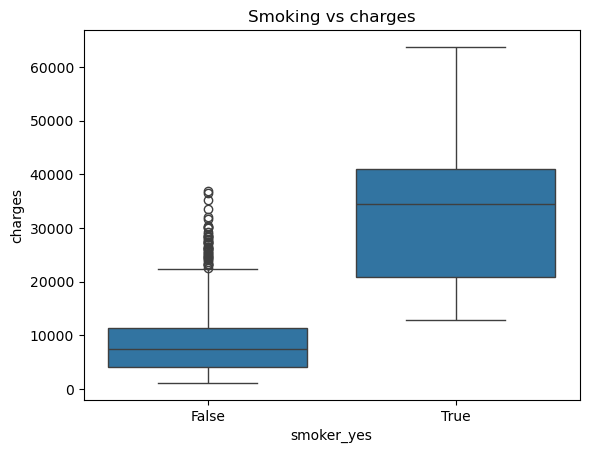

In [18]:
sns.boxplot(x="smoker_yes", y="charges", data=df)
plt.title("Smoking vs charges")
plt.show()

In [19]:
#Model Evaluation MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4181.194473753653


In [ ]:
#Model Evaluation RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print